In [2]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
1,Loading and Preprocessing 

In [ ]:
● Load the California Housing dataset using the fetch_california_housing function
from sklearn.
● Convert the dataset into a pandas DataFrame for easier handling. Handle
missing values (if any) and perform necessary feature scaling (e.g.,
standardization).
● Explain the preprocessing steps you performed and justify why they are
necessary for this dataset.

In [9]:
housing = fetch_california_housing()

print(housing.data.shape)
print(housing.target.shape)

(20640, 8)
(20640,)


In [10]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [11]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["MedHouseVal"] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [12]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [13]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16512, 8)
(4128, 8)


In [ ]:
Preprocessing Steps

In [ ]:
#Load the dataset
The California Housing dataset was loaded using fetch_california_housing().
#Convert to DataFrame
The dataset was converted into a pandas DataFrame for easy data handling.
#Check missing values
Missing values were checked using isnull().sum(). No missing values were found.
#Separate features and target
The input features were separated from the target variable MedHouseVal.
#Split the data
The data was divided into 80% training data and 20% testing data.
#Feature scaling
StandardScaler was used to scale the features. Scaling is important because the features have different ranges. It is especially useful for SVR.

In [ ]:
Why preprocessing is necessary
 Preprocessing helps to prepare the data for machine learning models.
It helps handle missing values, separates input and output variables,
and makes the features suitable for training. 
Feature scaling is important for models such as SVR because they are affected by different feature ranges.

In [ ]:
2. Regression Algorithm Implementation (5 marks):
● Implement the following regression algorithms:
○ Linear Regression
○ Decision Tree Regressor
○ Random Forest Regressor
○ Gradient Boosting Regressor
○ Support Vector Regressor (SVR)
● For each algorithm: Provide a brief explanation of how it works. Explain why it
might be suitable for this dataset.

In [ ]:
Linear Regression

In [16]:
#Model create
linear_model = LinearRegression()
#Train
linear_model.fit(X_train_scaled, y_train)
#Prediction
y_pred_linear = linear_model.predict(X_test_scaled)
print(y_pred_linear[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [ ]:
How it works: It finds a linear relationship between the features and the target.
Why suitable: It is simple and useful as a baseline model for predicting house prices.

Linear Regression

Linear Regression is a supervised learning algorithm used to predict a continuous target variable.

It finds a linear relationship between the input features and the target variable.

In [ ]:
Decision Tree Regressor

In [17]:
#Model
tree_model = DecisionTreeRegressor(random_state=42)
#Train
tree_model.fit(X_train, y_train)
#Prediction
y_pred_tree = tree_model.predict(X_test)
print(y_pred_tree[:5])

[0.414   1.203   5.00001 2.17    2.257  ]


In [ ]:
How it works: It splits the data using conditions and makes predictions.
Why suitable: It can find nonlinear patterns in the housing data.

Decision Tree Regressor

Decision Tree Regressor is a supervised learning algorithm that predicts a continuous target variable by making a series of decisions based on feature values.

It can capture non-linear relationships in the data and does not require feature scaling.

In [ ]:
Random Forest Regressor

In [18]:
#Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
#Train
rf_model.fit(X_train, y_train)
#Prediction
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf[:5])

[0.5095    0.74161   4.9232571 2.52961   2.27369  ]


In [ ]:
How it works: It uses many Decision Trees and combines their predictions.
Why suitable: It can handle complex data and usually gives better and more stable predictions.

Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to make predictions.

It can handle non-linear relationships and usually provides better and more stable predictions than a single decision tree.

In [ ]:
Gradient Boosting Regressor

In [19]:
#Model
gb_model = GradientBoostingRegressor(random_state=42)
#Train
gb_model.fit(X_train, y_train)
#Prediction
y_pred_gb = gb_model.predict(X_test)
print(y_pred_gb[:5])

[0.50518761 1.09334601 4.24570956 2.54517359 2.27910301]


In [ ]:
How it works: It builds trees one by one, with each tree trying to correct the previous errors.
Why suitable: It can learn complex patterns in the California Housing dataset.

Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds multiple decision trees sequentially.

Each new tree tries to reduce the errors made by the previous trees.

It is useful for capturing complex and non-linear relationships in the data.

In [ ]:
Support Vector Regressor — SVR

In [20]:
#Model
svr_model = SVR()
#Train
svr_model.fit(X_train_scaled, y_train)
#Prediction
y_pred_svr = svr_model.predict(X_test_scaled)
print(y_pred_svr[:5])

[0.51647228 1.56842925 3.59780295 2.49108208 2.56880838]


In [ ]:
How it works: It finds the best function to predict the target within a certain error margin.
Why suitable: It can handle nonlinear relationships, but feature scaling is important.

Support Vector Regressor (SVR)

Support Vector Regression is a supervised learning algorithm used to predict continuous values.

SVR tries to find a suitable function that keeps prediction errors within a specified margin.

Feature scaling is important for SVR because it is sensitive to the scale of the features.

In [ ]:
3. Model Evaluation and Comparison (2 marks):
● Evaluate the performance of each algorithm using the following metrics:
○ Mean Squared Error (MSE)
○ Mean Absolute Error (MAE)
○ R-squared Score (R2)
● Compare the results of all models and identify: The best-performing algorithm
with justification and the worst-performing algorithm with reasoning.

In [21]:
results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    
    "MSE": [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_tree),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_gb),
        mean_squared_error(y_test, y_pred_svr)
    ],
    
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_svr)
    ],
    
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_svr)
    ]
}

results_df = pd.DataFrame(results)

print(results_df.round(4))

               Model     MSE     MAE      R2
0  Linear Regression  0.5559  0.5332  0.5758
1      Decision Tree  0.4952  0.4547  0.6221
2      Random Forest  0.2554  0.3275  0.8051
3  Gradient Boosting  0.2940  0.3716  0.7756
4                SVR  0.3570  0.3986  0.7276


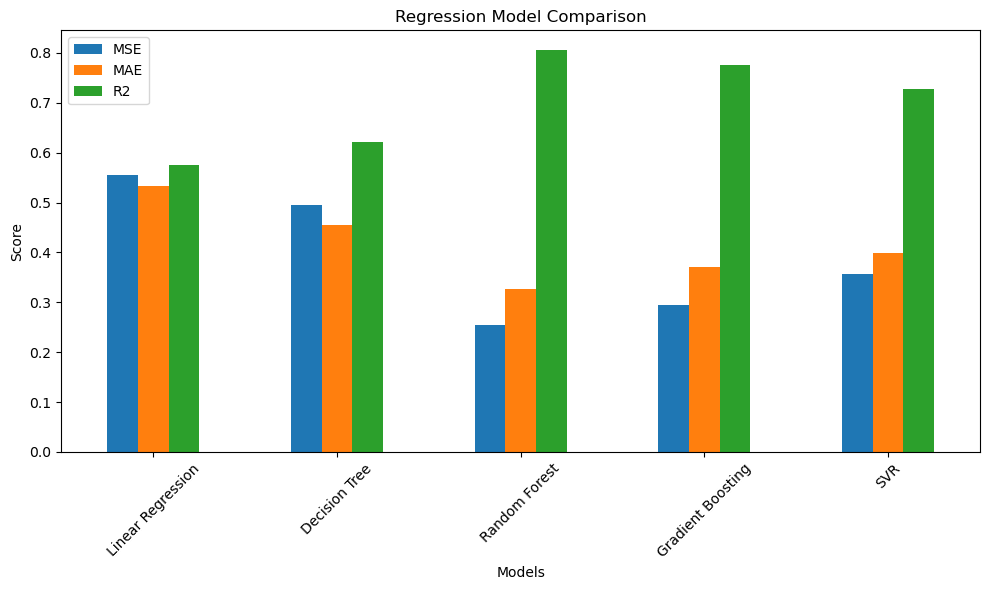

In [22]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["MSE", "MAE", "R2"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regression Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Model Evaluation and Comparison

The models were evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² score.

Lower MSE and MAE indicate better performance, while a higher R² score indicates better performance.

Random Forest Regressor performed the best with the lowest MSE and MAE and the highest R² score.

Linear Regression performed the worst among the five models tested.

In [ ]:
Model	                      MSE	            MAE	      R²
Linear Regression	          0.5559	       0.5332	0.5758
Decision Tree	              0.4952	       0.4547	0.6221
Random Forest	              0.2554	       0.3275	0.8051
Gradient Boosting	          0.2940	       0.3716	0.7756
SVR	                          0.3570	       0.3986	0.7276

In [ ]:
Best-performing algorithm: Random Forest Regressor.
It has the lowest MSE and MAE and the highest R² score (0.8051).
Therefore, it gives the best performance.

In [ ]:
Worst-performing algorithm: Linear Regression.
It has the highest MSE and MAE and the lowest R² score (0.5758). 
Therefore, it gives the worst performance among the five models.

Final Conclusion

Among the five regression algorithms, Random Forest Regressor performed the best.

It achieved the lowest MSE (0.2554), lowest MAE (0.3275), and highest R² score (0.8051).

Linear Regression performed the worst among the tested models because it had the highest MSE and MAE and the lowest R² score.

Therefore, Random Forest Regressor is the most suitable model for this California Housing dataset among the models tested.